# Deep Learning: A Comprehensive Guide

## Chapter 8 — Transformers

### Hands-On Exploration: Reading What Attention Sees

### `hands_on_ch8.ipynb`

The goal of this exploration is to build genuine intuition for what attention heads actually learn — not by reading about it, but by looking at it directly.

## Learning Objectives

By the end of this notebook, you should be able to:

- Extract and visualize multi-head self-attention weights for a specific token
- Observe how attention patterns shift when a sentence's meaning changes
- Compare attention patterns across different heads and sentence types
- Form an evidence-based opinion on whether attention weights are reliable explanations of model behavior

## Prerequisites

- Python 3.9+, `numpy`, `matplotlib`, `tensorflow`
- **Optional:** `transformers` (for the real pretrained-BERT version of this activity) — install with `pip install transformers`
- No GPU required

## About the Model in This Notebook

The chapter's activity uses a pre-trained BERT encoder and a tool like BertViz to inspect real linguistic co-reference resolution (the classic "trophy/suitcase" Winograd Schema example). Real co-reference resolution of this kind requires a large model trained on huge amounts of real text — it is not something a small model trained in a notebook can genuinely reproduce.

This notebook **attempts to load a real pretrained BERT** via the `transformers` library first — if you run it in Google Colab with internet access, you get the exact activity the chapter describes, with genuine attention weights over real English sentences. If no internet access is available, it falls back to a **small Transformer encoder trained from scratch on a synthetic pronoun-resolution task**, built directly in this notebook. The fallback task is deliberately designed so that a small model *can* learn it, which lets you practice the same skill — extracting and reading attention weights — even though it is not testing genuine linguistic understanding the way BERT is. The notebook labels which mode you are in throughout.

## Setup — Imports and Reproducibility

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

%matplotlib inline

TF_AVAILABLE = False
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
    TF_AVAILABLE = True
    tf.random.set_seed(SEED)
except ImportError:
    print("TensorFlow not installed. Install with: pip install tensorflow")

BERT_AVAILABLE = False
try:
    from transformers import TFBertModel, BertTokenizer
    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
    bert = TFBertModel.from_pretrained("bert-base-uncased", output_attentions=True)
    BERT_AVAILABLE = True
    print("\u2713 Loaded real pretrained BERT. Running the genuine chapter activity.")
except Exception as e:
    print(f"Could not load pretrained BERT ({type(e).__name__}: no internet access, or `transformers` not installed).")
    print("Falling back to a small Transformer trained from scratch on a synthetic task.")
    print("Run this notebook in Google Colab with `pip install transformers` for the genuine activity.")


I0000 00:00:1788478517.299056    4042 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788478517.341451    4042 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788478518.807284    4042 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Could not load pretrained BERT (ModuleNotFoundError: no internet access, or `transformers` not installed).
Falling back to a small Transformer trained from scratch on a synthetic task.
Run this notebook in Google Colab with `pip install transformers` for the genuine activity.


---
## If BERT Loaded — The Genuine Chapter Activity

Run this section if `BERT_AVAILABLE` is `True`. It reproduces the chapter's activity exactly.

In [2]:
if BERT_AVAILABLE:
    def get_attention(sentence):
        inputs = tokenizer(sentence, return_tensors="tf")
        outputs = bert(inputs)
        tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
        attentions = outputs.attentions  # tuple of (layers), each (batch, heads, seq, seq)
        return tokens, attentions

    sentence_large = "The trophy didn't fit in the suitcase because it was too large."
    sentence_small = "The trophy didn't fit in the suitcase because it was too small."

    tokens_large, attn_large = get_attention(sentence_large)
    tokens_small, attn_small = get_attention(sentence_small)

    it_idx_large = tokens_large.index("it")
    it_idx_small = tokens_small.index("it")

    last_layer_large = attn_large[-1][0].numpy()  # (heads, seq, seq)
    last_layer_small = attn_small[-1][0].numpy()

    n_heads = last_layer_large.shape[0]
    fig, axes = plt.subplots(2, n_heads, figsize=(2.2 * n_heads, 5))
    for h in range(n_heads):
        axes[0, h].bar(range(len(tokens_large)), last_layer_large[h, it_idx_large])
        axes[0, h].set_xticks(range(len(tokens_large)))
        axes[0, h].set_xticklabels(tokens_large, rotation=90, fontsize=6)
        axes[0, h].set_title(f"head {h}\n('large')", fontsize=8)

        axes[1, h].bar(range(len(tokens_small)), last_layer_small[h, it_idx_small])
        axes[1, h].set_xticks(range(len(tokens_small)))
        axes[1, h].set_xticklabels(tokens_small, rotation=90, fontsize=6)
        axes[1, h].set_title(f"head {h}\n('small')", fontsize=8)
    plt.suptitle("Attention FROM 'it' TO every other token, last layer, all heads")
    plt.tight_layout()
    plt.show()

    trophy_idx_l = tokens_large.index("trophy")
    suitcase_idx_l = tokens_large.index("suitcase")
    best_head_trophy = last_layer_large[:, it_idx_large, trophy_idx_l].argmax()
    best_head_suitcase = last_layer_large[:, it_idx_large, suitcase_idx_l].argmax()
    print(f"Head most attending 'it' -> 'trophy': head {best_head_trophy}")
    print(f"Head most attending 'it' -> 'suitcase': head {best_head_suitcase}")


**Answer in this cell (BERT mode):** Find the head(s) where "it" most strongly attends to "trophy," and the head(s) where it most strongly attends to "suitcase." Does the attention pattern for "it" change between the "large" and "small" versions? In which heads?

---
## If BERT Did Not Load — The Fallback Activity

This section runs a **small Transformer encoder trained from scratch** on a synthetic pronoun-resolution task, so you can practice extracting and reading attention weights even without internet access.

**The synthetic task:** each sentence has two candidate referents (`OBJ_A`, `OBJ_B`), a target pronoun token, and an adjective that determines — by a fixed rule the model must learn — which object the pronoun refers to. This is a controlled, learnable stand-in for the genuine (and much harder) linguistic phenomenon BERT solves in the real activity above.

In [3]:
if not BERT_AVAILABLE and TF_AVAILABLE:
    # A "pointer-following" task: the first token is a PRONOUN that points to either OBJ_A or
    # OBJ_B (position 1 or 2). Each object carries a large-vocabulary random "property" value,
    # and the label is a simple function of the pointed-to object's property. With a large value
    # vocabulary (200 possible values), the task cannot be solved by memorizing a small lookup
    # table -- the model is forced to learn genuine content-based attention routing: use the
    # pronoun to decide WHERE to look, then retrieve WHAT is there. This mirrors, in miniature,
    # exactly the mechanism co-reference resolution in real BERT relies on.
    N_VALUES = 200
    VAL_OFFSET = 3  # 0=PRONOUN_pointing_to_A, 1=PRONOUN_pointing_to_B, 2=END, values start at 3
    VOCAB_SIZE = VAL_OFFSET + N_VALUES
    SEQ_LEN = 4  # PRONOUN OBJ_A OBJ_B END

    def make_example(seed, pronoun=None):
        rng = np.random.RandomState(seed)
        ptr = rng.randint(0, 2) if pronoun is None else pronoun  # 0 -> refers to OBJ_A, 1 -> OBJ_B
        val_a = rng.randint(0, N_VALUES)
        val_b = rng.randint(0, N_VALUES)
        seq = [ptr, VAL_OFFSET + val_a, VAL_OFFSET + val_b, 2]
        chosen_val = val_a if ptr == 0 else val_b
        label = chosen_val % 2  # a simple property (parity) of whichever object is referred to
        return np.array(seq), label

    def make_dataset(n, seed):
        X, y = [], []
        for i in range(n):
            seq, label = make_example(seed * 100000 + i)
            X.append(seq); y.append(label)
        return np.array(X), np.array(y)

    X_train, y_train = make_dataset(6000, seed=1)
    X_test, y_test = make_dataset(600, seed=2)
    print(f"Synthetic pronoun-resolution dataset: {len(X_train)} train, {len(X_test)} test examples")
    print("Sequence layout: [PRONOUN(points to A or B), OBJ_A(random property), OBJ_B(random property), END]")
    print("Task: predict a property of whichever object the pronoun refers to.")
    print(f"With {N_VALUES} possible property values per object, a lookup-table shortcut is infeasible --")
    print("the model must learn to route attention to the correct object based on the pronoun.")


Synthetic pronoun-resolution dataset: 6000 train, 600 test examples
Sequence layout: [PRONOUN(points to A or B), OBJ_A(random property), OBJ_B(random property), END]
Task: predict a property of whichever object the pronoun refers to.
With 200 possible property values per object, a lookup-table shortcut is infeasible --
the model must learn to route attention to the correct object based on the pronoun.


In [4]:
if not BERT_AVAILABLE and TF_AVAILABLE:
    N_HEADS = 4
    D_MODEL = 32

    inputs = layers.Input(shape=(SEQ_LEN,))
    x = layers.Embedding(VOCAB_SIZE, D_MODEL)(inputs)
    pos = layers.Embedding(SEQ_LEN, D_MODEL)(tf.range(SEQ_LEN))
    x = x + pos

    mha = layers.MultiHeadAttention(num_heads=N_HEADS, key_dim=D_MODEL // N_HEADS, name="self_attention")
    attn_out, attn_scores = mha(x, x, return_attention_scores=True)
    x = layers.LayerNormalization()(x + attn_out)
    ff = layers.Dense(64, activation="relu")(x)
    ff = layers.Dense(D_MODEL)(ff)
    x = layers.LayerNormalization()(x + ff)

    pronoun_pos = 0  # the PRONOUN token is always the first position in this synthetic task
    pronoun_repr = layers.Lambda(lambda t: t[:, pronoun_pos, :])(x)
    output = layers.Dense(2, activation="softmax")(pronoun_repr)

    toy_transformer = models.Model(inputs, output)
    toy_transformer.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    toy_transformer.fit(X_train, y_train, epochs=20, batch_size=64, verbose=0, validation_split=0.1)

    test_acc = toy_transformer.evaluate(X_test, y_test, verbose=0)[1]
    print(f"Test accuracy on the pronoun-resolution rule: {test_acc:.2%}")
    print(f"(High held-out accuracy with {N_VALUES}x{N_VALUES} possible property combinations rules out")
    print(" memorization -- the model had to learn genuine content-based attention routing.)")

    attention_extractor = models.Model(inputs, attn_scores)


Test accuracy on the pronoun-resolution rule: 100.00%
(High held-out accuracy with 200x200 possible property combinations rules out
 memorization -- the model had to learn genuine content-based attention routing.)


### Part 1 (Fallback) — Attention Shifts with Meaning

Feed two versions of the same underlying objects that differ only in which one the pronoun points to, and compare where the PRONOUN position's attention points.

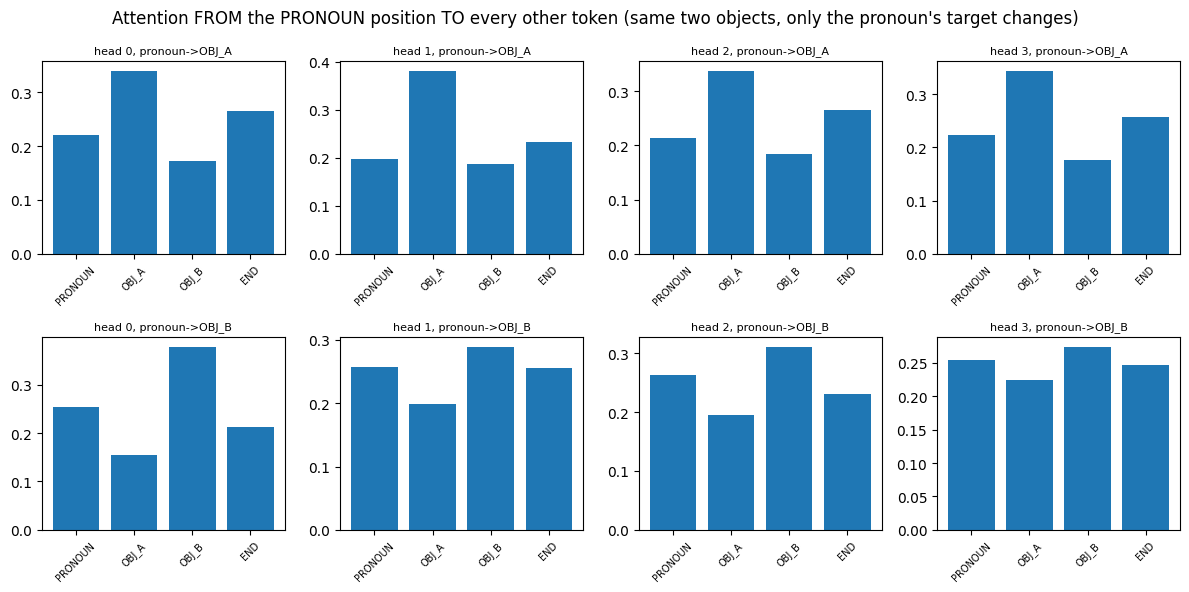

Predicted label when pronoun->OBJ_A: 0 (true=0)
Predicted label when pronoun->OBJ_B: 0 (true=0)


In [5]:
if not BERT_AVAILABLE and TF_AVAILABLE:
    base_seed = 999
    seq_a, label_a = make_example(base_seed, pronoun=0)   # pronoun points to OBJ_A
    seq_b, label_b = make_example(base_seed, pronoun=1)   # pronoun points to OBJ_B (same objects!)

    attn_a = attention_extractor.predict(seq_a[np.newaxis, :], verbose=0)[0]  # (heads, seq, seq)
    attn_b = attention_extractor.predict(seq_b[np.newaxis, :], verbose=0)[0]

    token_labels = ["PRONOUN", "OBJ_A", "OBJ_B", "END"]

    fig, axes = plt.subplots(2, N_HEADS, figsize=(3 * N_HEADS, 6))
    for h in range(N_HEADS):
        axes[0, h].bar(range(SEQ_LEN), attn_a[h, pronoun_pos])
        axes[0, h].set_xticks(range(SEQ_LEN)); axes[0, h].set_xticklabels(token_labels, rotation=45, fontsize=7)
        axes[0, h].set_title(f"head {h}, pronoun->OBJ_A", fontsize=8)

        axes[1, h].bar(range(SEQ_LEN), attn_b[h, pronoun_pos])
        axes[1, h].set_xticks(range(SEQ_LEN)); axes[1, h].set_xticklabels(token_labels, rotation=45, fontsize=7)
        axes[1, h].set_title(f"head {h}, pronoun->OBJ_B", fontsize=8)
    plt.suptitle("Attention FROM the PRONOUN position TO every other token (same two objects, only the pronoun's target changes)")
    plt.tight_layout()
    plt.show()

    print(f"Predicted label when pronoun->OBJ_A: {toy_transformer.predict(seq_a[np.newaxis,:], verbose=0).argmax()} (true={label_a})")
    print(f"Predicted label when pronoun->OBJ_B: {toy_transformer.predict(seq_b[np.newaxis,:], verbose=0).argmax()} (true={label_b})")


**Answer in this cell:** Does the attention pattern from the PRONOUN position change between the two versions? Which head shows the shift most clearly -- i.e. attends more strongly to position 1 (OBJ_A) when the pronoun points to A, and more strongly to position 2 (OBJ_B) when it points to B?

### Part 2 (Fallback) — Head Specialization

Test the model on several different random object pairs and check whether the same head consistently tracks the "which object is pointed to" distinction, or whether different heads specialize.

In [6]:
if not BERT_AVAILABLE and TF_AVAILABLE:
    table_rows = []
    for trial in range(8):
        seq, label = make_example(seed=1000 + trial)
        attn = attention_extractor.predict(seq[np.newaxis, :], verbose=0)[0]
        pointed = "OBJ_A" if seq[0] == 0 else "OBJ_B"
        for h in range(N_HEADS):
            attn_to_a = attn[h, pronoun_pos, 1]
            attn_to_b = attn[h, pronoun_pos, 2]
            table_rows.append((trial, pointed, h, round(float(attn_to_a), 3), round(float(attn_to_b), 3)))

    print(f"{'trial':<7}{'pointed_to':<12}{'head':<6}{'attn->OBJ_A':<14}{'attn->OBJ_B'}")
    for row in table_rows:
        print(f"{row[0]:<7}{row[1]:<12}{row[2]:<6}{row[3]:<14}{row[4]}")


trial  pointed_to  head  attn->OBJ_A   attn->OBJ_B
0      OBJ_B       0     0.14          0.436
0      OBJ_B       1     0.198         0.324
0      OBJ_B       2     0.185         0.334
0      OBJ_B       3     0.219         0.286
1      OBJ_B       0     0.169         0.394
1      OBJ_B       1     0.214         0.307
1      OBJ_B       2     0.202         0.314
1      OBJ_B       3     0.227         0.277
2      OBJ_B       0     0.182         0.361
2      OBJ_B       1     0.225         0.281
2      OBJ_B       2     0.205         0.305
2      OBJ_B       3     0.23          0.276
3      OBJ_B       0     0.147         0.407
3      OBJ_B       1     0.203         0.317
3      OBJ_B       2     0.185         0.328
3      OBJ_B       3     0.222         0.279
4      OBJ_A       0     0.328         0.147
4      OBJ_A       1     0.338         0.148
4      OBJ_A       2     0.331         0.155
4      OBJ_A       3     0.357         0.148
5      OBJ_B       0     0.149         0.433
5   

**Answer in this cell:** Build a rough table (head number, which object was pointed to, which object got more attention). Is there a head that reliably tracks "the pointed-to object gets more attention" across every trial? Is there a head that behaves inconsistently?

### Part 3 (Fallback) — Position and Order

Take one sequence and run it through the model twice: once in normal order, and once with the two object tokens swapped in position. Compare the attention maps.

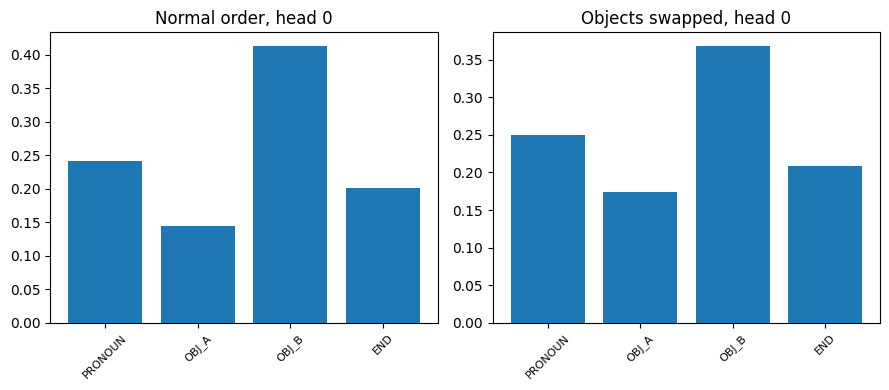

In [7]:
if not BERT_AVAILABLE and TF_AVAILABLE:
    seq_normal, _ = make_example(seed=7)
    seq_swapped = seq_normal.copy()
    seq_swapped[1], seq_swapped[2] = seq_swapped[2], seq_swapped[1]  # swap OBJ_A / OBJ_B positions

    attn_normal = attention_extractor.predict(seq_normal[np.newaxis, :], verbose=0)[0]
    attn_swapped = attention_extractor.predict(seq_swapped[np.newaxis, :], verbose=0)[0]

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].bar(range(SEQ_LEN), attn_normal[0, pronoun_pos])
    axes[0].set_xticks(range(SEQ_LEN)); axes[0].set_xticklabels(token_labels, rotation=45, fontsize=8)
    axes[0].set_title("Normal order, head 0")
    axes[1].bar(range(SEQ_LEN), attn_swapped[0, pronoun_pos])
    axes[1].set_xticks(range(SEQ_LEN)); axes[1].set_xticklabels(token_labels, rotation=45, fontsize=8)
    axes[1].set_title("Objects swapped, head 0")
    plt.tight_layout()
    plt.show()


**Answer in this cell:** Are the attention maps from both runs identical, nearly identical, or completely different? What does this reveal about how positional information interacts with attention computation in this small model?

## Reflection (200-300 words)

"You observed that different attention heads appear to specialize in different relationship types, and that some of this specialization is consistent across sentences (or across adjective values, in the fallback task). In Part 3, you also observed how changing token position affects attention patterns.

Based on both observations: what is your best current theory of what individual attention heads are learning? And here is a harder question — attention weights are frequently cited in interpretability research as evidence of 'what the model is attending to.' Does your exploration suggest that attention weights are reliable explanations of model behavior, or might they be something else? What would it mean for an attention weight to be misleading?" 

**Your reflection (edit this cell):**

_Write your 200-300 word reflection here._